# Experiment 10 - Vision Transformer vs ResNet-18
**Dataset:** CIFAR-10 | **Models:** ViT, ResNet-18

In [1]:
!pip install wandb huggingface_hub -q

In [2]:
import wandb
wandb.login()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: ashishk200088 (ashishk200088-delhi-technological-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [3]:
from huggingface_hub import notebook_login
notebook_login()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [18]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
import matplotlib.pyplot as plt
import numpy as np
import os
from torch.utils.data import DataLoader, random_split
from huggingface_hub import HfApi, create_repo

# change to your huggingface username
HF_REPO = "<YOUR_HF_USERNAME>/exp10-vit-resnet" # <<< FIX THIS! Replace <YOUR_HF_USERNAME> with your actual Hugging Face username

WANDB_PROJECT = "exp10-vit-resnet"
EPOCHS        = 2
BATCH_SIZE    = 128
NUM_CLASSES   = 10
PATCH_SIZE    = 4
IMG_SIZE      = 32
EMBED_DIM     = 128
NUM_HEADS     = 4
NUM_LAYERS    = 4
DEVICE        = torch.device("cuda" if torch.cuda.is_available() else "cpu")

LOSS_FNS   = ["ce", "label_smooth", "focal"]
OPTIMIZERS = ["adam", "sgd", "rmsprop"]
MODELS     = ["vit", "resnet18"]
AUG_MODES  = ["no_aug", "aug"]

class_names = ['plane','car','bird','cat','deer','dog','frog','horse','ship','truck']
print(DEVICE)

cuda


### Dataset - Original and Augmented

100%|██████████| 170M/170M [00:06<00:00, 27.9MB/s]


train=40000  val=10000  test=10000


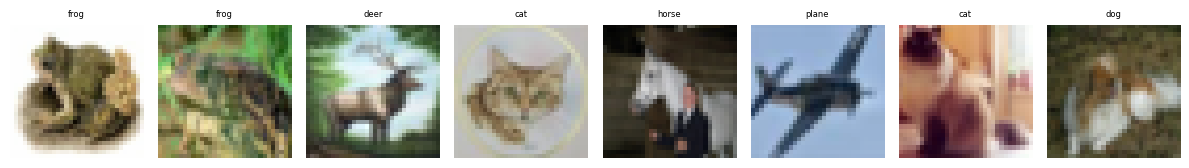

In [5]:
mean = (0.4914, 0.4822, 0.4465)
std  = (0.2023, 0.1994, 0.2010)

# without augmentation
transform_base = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

# with horizontal + vertical flip
transform_aug = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

full_base = torchvision.datasets.CIFAR10(root='./data', train=True,  download=True, transform=transform_base)
full_aug  = torchvision.datasets.CIFAR10(root='./data', train=True,  download=True, transform=transform_aug)
test_data = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)

n_total = len(full_base)        # 50000
n_train = int(0.8 * n_total)   # 40000
n_val   = n_total - n_train    # 10000

gen = torch.Generator().manual_seed(42)
train_base, val_base = random_split(full_base, [n_train, n_val], generator=gen)
train_aug,  val_aug  = random_split(full_aug,  [n_train, n_val], generator=torch.Generator().manual_seed(42))

def make_loaders(train_set, val_set):
    tr = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
    vl = DataLoader(val_set,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
    te = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
    return tr, vl, te

loaders = {
    'no_aug': make_loaders(train_base, val_base),
    'aug':    make_loaders(train_aug,  val_aug)
}

print(f'train={n_train}  val={n_val}  test={len(test_data)}')

imgs, labels = next(iter(loaders['no_aug'][0]))
fig, axes = plt.subplots(1, 8, figsize=(12, 2))
for i in range(8):
    img = imgs[i].permute(1,2,0).numpy()
    img = img * np.array(std) + np.array(mean)
    axes[i].imshow(np.clip(img, 0, 1))
    axes[i].set_title(class_names[labels[i]], fontsize=6)
    axes[i].axis('off')
plt.tight_layout()
plt.show()

### Patch Embedding

In [6]:
class PatchEmbedding(nn.Module):
    def __init__(self, img_size, patch_size, in_channels, embed_dim):
        super(PatchEmbedding, self).__init__()
        self.num_patches = (img_size // patch_size) ** 2
        # use conv to split image into patches and project
        self.proj = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        x = self.proj(x)           # (B, embed_dim, H/p, W/p)
        x = x.flatten(2)           # (B, embed_dim, num_patches)
        x = x.transpose(1, 2)     # (B, num_patches, embed_dim)
        return x

### Vision Transformer

In [7]:
class ViT(nn.Module):
    def __init__(self, img_size=32, patch_size=4, in_channels=3,
                 embed_dim=128, num_heads=4, num_layers=4, num_classes=10):
        super(ViT, self).__init__()

        self.patch_embed  = PatchEmbedding(img_size, patch_size, in_channels, embed_dim)
        num_patches       = (img_size // patch_size) ** 2

        # learnable CLS token
        self.cls_token    = nn.Parameter(torch.zeros(1, 1, embed_dim))
        # learnable positional encoding
        self.pos_embed    = nn.Parameter(torch.zeros(1, num_patches + 1, embed_dim))

        encoder_layer     = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=num_heads,
            dim_feedforward=embed_dim * 4,
            dropout=0.1, batch_first=True
        )
        self.transformer  = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.norm         = nn.LayerNorm(embed_dim)

        # classification head
        self.head = nn.Sequential(
            nn.Linear(embed_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(256, num_classes)
        )

        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)

    def forward(self, x):
        B = x.size(0)
        x = self.patch_embed(x)

        cls = self.cls_token.expand(B, -1, -1)
        x   = torch.cat([cls, x], dim=1)
        x   = x + self.pos_embed

        x   = self.transformer(x)
        x   = self.norm(x)
        # take CLS token output for classification
        out = self.head(x[:, 0])
        return out

### ResNet-18 Baseline

In [8]:
def get_resnet18():
    model = models.resnet18(weights=None)
    # adjust first conv for 32x32 input
    model.conv1   = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.maxpool = nn.Identity()
    model.fc      = nn.Linear(512, NUM_CLASSES)
    return model

### Loss Functions - CE, Label Smoothing, Focal

In [9]:
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0):
        super(FocalLoss, self).__init__()
        self.gamma = gamma

    def forward(self, logits, targets):
        ce   = nn.functional.cross_entropy(logits, targets, reduction='none')
        pt   = torch.exp(-ce)
        loss = ((1 - pt) ** self.gamma) * ce
        return loss.mean()

def get_criterion(loss_type):
    if loss_type == 'ce':
        return nn.CrossEntropyLoss()
    elif loss_type == 'label_smooth':
        return nn.CrossEntropyLoss(label_smoothing=0.1)
    elif loss_type == 'focal':
        return FocalLoss(gamma=2.0)

### Optimizer Factory

In [10]:
def get_optimizer(model, name):
    if name == 'adam':
        return optim.Adam(model.parameters(), lr=1e-3)
    elif name == 'sgd':
        return optim.SGD(model.parameters(), lr=1e-2, momentum=0.9, weight_decay=5e-4)
    else:
        return optim.RMSprop(model.parameters(), lr=1e-3)

### Train and Eval Loops

In [11]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    correct    = 0
    total      = 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        out  = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct    += (out.argmax(1) == y).sum().item()
        total      += y.size(0)
    return total_loss / len(loader), correct / total

def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0
    correct    = 0
    total      = 0
    with torch.no_grad():
        for x, y in loader:
            x, y  = x.to(DEVICE), y.to(DEVICE)
            out   = model(x)
            loss  = criterion(out, y)
            total_loss += loss.item()
            correct    += (out.argmax(1) == y).sum().item()
            total      += y.size(0)
    return total_loss / len(loader), correct / total

### Main Experiment Runner

In [12]:
results       = {}
saved_models  = {}

def run_experiment(arch, loss_type, opt_name, aug_mode):
    name = f'{arch}_{loss_type}_{opt_name}_{aug_mode}'
    print(f'\nstarting: {name}')

    wandb.init(project=WANDB_PROJECT, name=name, config={
        'arch': arch, 'loss': loss_type,
        'optimizer': opt_name, 'augmentation': aug_mode, 'epochs': EPOCHS
    })

    train_loader, val_loader, test_loader = loaders[aug_mode]

    if arch == 'vit':
        model = ViT(
            img_size=IMG_SIZE, patch_size=PATCH_SIZE, in_channels=3,
            embed_dim=EMBED_DIM, num_heads=NUM_HEADS,
            num_layers=NUM_LAYERS, num_classes=NUM_CLASSES
        ).to(DEVICE)
    else:
        model = get_resnet18().to(DEVICE)

    criterion = get_criterion(loss_type)
    optimizer = get_optimizer(model, opt_name)

    best_val_acc = 0

    for epoch in range(1, EPOCHS + 1):
        tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion)
        vl_loss, vl_acc = evaluate(model, val_loader, criterion)

        if vl_acc > best_val_acc:
            best_val_acc = vl_acc
            torch.save(model.state_dict(), f'{name}_best.pt')

        wandb.log({
            'epoch': epoch,
            'train_loss': tr_loss, 'train_acc': tr_acc,
            'val_loss':   vl_loss, 'val_acc':   vl_acc
        })
        print(f'  epoch {epoch}/{EPOCHS}  train_loss={tr_loss:.4f}  train_acc={tr_acc:.4f}  val_loss={vl_loss:.4f}  val_acc={vl_acc:.4f}')

    # load best checkpoint and test
    model.load_state_dict(torch.load(f'{name}_best.pt'))
    te_loss, te_acc = evaluate(model, test_loader, criterion)
    print(f'  test_loss={te_loss:.4f}  test_acc={te_acc:.4f}')
    wandb.log({'test_loss': te_loss, 'test_acc': te_acc})

    results[name]      = {'test_acc': te_acc, 'test_loss': te_loss}
    saved_models[name] = model

    wandb.finish()
    return model

### Quick Test - run this first

In [13]:
run_experiment('vit',      'ce', 'adam', 'no_aug')
run_experiment('resnet18', 'ce', 'adam', 'no_aug')


starting: vit_ce_adam_no_aug


  epoch 1/2  train_loss=1.7834  train_acc=0.3279  val_loss=1.5441  val_acc=0.4290
  epoch 2/2  train_loss=1.4404  train_acc=0.4688  val_loss=1.2910  val_acc=0.5230
  test_loss=1.3087  test_acc=0.5217


epoch,▁█
test_acc,▁
test_loss,▁
train_acc,▁█
train_loss,█▁
val_acc,▁█
val_loss,█▁
epoch,2
test_acc,0.5217
test_loss,1.30874
train_acc,0.46877



starting: resnet18_ce_adam_no_aug


  epoch 1/2  train_loss=1.2732  train_acc=0.5361  val_loss=1.6067  val_acc=0.4752
  epoch 2/2  train_loss=0.7827  train_acc=0.7238  val_loss=1.0709  val_acc=0.6673
  test_loss=1.0914  test_acc=0.6681


epoch,▁█
test_acc,▁
test_loss,▁
train_acc,▁█
train_loss,█▁
val_acc,▁█
val_loss,█▁
epoch,2
test_acc,0.6681
test_loss,1.09142
train_acc,0.72385


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): Identity()
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), p

### Full Grid - all combinations

In [14]:
for arch in MODELS:
    for aug in AUG_MODES:
        for lf in LOSS_FNS:
            for opt in OPTIMIZERS:
                run_experiment(arch, lf, opt, aug)


starting: vit_ce_adam_no_aug


  epoch 1/2  train_loss=1.7940  train_acc=0.3256  val_loss=1.5842  val_acc=0.4181
  epoch 2/2  train_loss=1.4480  train_acc=0.4659  val_loss=1.3324  val_acc=0.5092
  test_loss=1.3388  test_acc=0.5138


epoch,▁█
test_acc,▁
test_loss,▁
train_acc,▁█
train_loss,█▁
val_acc,▁█
val_loss,█▁
epoch,2
test_acc,0.5138
test_loss,1.33875
train_acc,0.46587



starting: vit_ce_sgd_no_aug


  epoch 1/2  train_loss=1.9035  train_acc=0.2908  val_loss=1.7523  val_acc=0.3521
  epoch 2/2  train_loss=1.6859  train_acc=0.3734  val_loss=1.6022  val_acc=0.4043
  test_loss=1.6086  test_acc=0.4023


...

  epoch 1/2  train_loss=1.1219  train_acc=0.3950  val_loss=0.9402  val_acc=0.4618
  epoch 2/2  train_loss=0.7713  train_acc=0.5520  val_loss=0.8681  val_acc=0.5180
  test_loss=0.8665  test_acc=0.5188


epoch,▁█
test_acc,▁
test_loss,▁
train_acc,▁█
train_loss,█▁
val_acc,▁█
val_loss,█▁
epoch,2
test_acc,0.5188
test_loss,0.86649
train_acc,0.552



starting: resnet18_focal_rmsprop_aug


  epoch 1/2  train_loss=1.2086  train_acc=0.3623  val_loss=0.9968  val_acc=0.4288
  epoch 2/2  train_loss=0.8186  train_acc=0.5238  val_loss=0.8217  val_acc=0.5312
  test_loss=0.8412  test_acc=0.5188


epoch,▁█
test_acc,▁
test_loss,▁
train_acc,▁█
train_loss,█▁
val_acc,▁█
val_loss,█▁
epoch,2
test_acc,0.5188
test_loss,0.84116
train_acc,0.52375


### Results Summary

In [15]:
print(f'{"config":<50} {"test_acc":>10} {"test_loss":>10}')
print('-' * 72)
for k, v in sorted(results.items(), key=lambda x: -x[1]['test_acc']):
    print(f'{k:<50} {v["test_acc"]:>10.4f} {v["test_loss"]:>10.4f}')

best = max(results, key=lambda x: results[x]['test_acc'])
print(f'\nbest: {best}  acc={results[best]["test_acc"]:.4f}')

config                                               test_acc  test_loss
------------------------------------------------------------------------
resnet18_ce_adam_no_aug                                0.7418     0.7447
resnet18_label_smooth_adam_no_aug                      0.7330     1.1037
resnet18_focal_adam_no_aug                             0.7070     0.4674
resnet18_ce_sgd_no_aug                                 0.6729     0.9325
resnet18_focal_adam_aug                                0.6386     0.5948
resnet18_label_smooth_rmsprop_no_aug                   0.6382     1.3068
resnet18_ce_adam_aug                                   0.6317     1.0261
resnet18_label_smooth_adam_aug                         0.6176     1.3543
resnet18_focal_sgd_no_aug                              0.6121     0.6601
resnet18_label_smooth_sgd_no_aug                       0.6093     1.3880
resnet18_focal_rmsprop_no_aug                          0.5958     0.6907
resnet18_ce_rmsprop_no_aug                         

### Upload to HuggingFace